---
str vs category 타입
- 문자열 컬럼을 category 타입으로 바꿨을 때 메모리가 얼마나 절약되는지 확인합니다.
- 반복되는 문자열 컬럼은 category로 바꾸는 것만으로도 메모리 사용량이 훨씬 줄어듭니다.
- object(str)는 "문자열을 10만 번 저장"하고, category는 "문자열 3개 + 숫자 10만 개만 저장"하기 때문입니다.

In [ ]:
import pandas as pd
import numpy as np

n_rows = 100000
species_list = ["Setosa", "Versicolor", "Virginica"]
data = np.random.choice(species_list, n_rows) # 100,000개의 랜덤한 종의 배열

df = pd.DataFrame({"Species": data})

In [2]:
mem_object = df["Species"].memory_usage(deep=True)

df["Species"] = df["Species"].astype("category")
mem_category = df["Species"].memory_usage(deep=True)

print(f"Object 타입 메모리: {mem_object:.2f} MB")
print(f"Category 타입 메모리: {mem_category:.2f} MB")
print(f"Object 타입 메모리: {(1 - mem_category/mem_object)*100:.1f}%")

Object 타입 메모리: 5733167.00 MB
Category 타입 메모리: 100304.00 MB
Object 타입 메모리: 98.3%


---
### Iris(붓꽃) 품종 종류

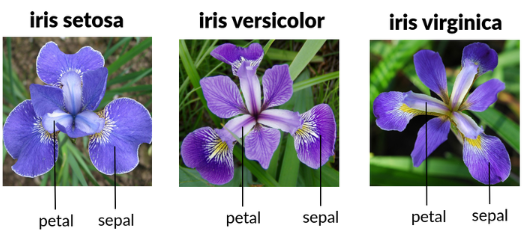

출처)https://velog.io/@sp1rit/Iris%EC%9D%98-%EC%84%B8%EA%B0%80%EC%A7%80-%ED%92%88%EC%A2%85-%EB%B6%84%EB%A5%98%ED%95%98%EA%B8%B0

---
CSV(comma-Separated Values)는 "쉼표로 구분된 값"이라는 뜻으로, 데이터를 저장하고 교환하는 데 가장 널리 쓰이는 텍스트 파일 형식입니다.
- 복잡한 서식 없이 순수하게 "텍스트"로만 이루어져 있어 매우 가볍고 호환성이 뛰어납니다.
- 파이썬의 Pandas 라이브러리를 사용하면 수만 줄의 CSV 파일도 단 한줄의 코드로 불러와 분석할 수 있습니다.

In [3]:
import pandas as pd
df = pd.read_csv("data/iris.csv")
print(df)

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal_Length  150 non-null    float64
 1   Sepal_Width   150 non-null    float64
 2   Petal_Length  150 non-null    float64
 3   Petal_Width   150 non-null    float64
 4   Species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None


In [5]:
print(df.shape)

(150, 5)


In [6]:
print(df.shape[0])
print(df.shape[1])

150
5


In [7]:
print(df.dtypes)

Sepal_Length    float64
Sepal_Width     float64
Petal_Length    float64
Petal_Width     float64
Species             str
dtype: object


In [8]:
df["Species"] = df["Species"].astype("category")
print(df.dtypes)

Sepal_Length     float64
Sepal_Width      float64
Petal_Length     float64
Petal_Width      float64
Species         category
dtype: object


In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Sepal_Length  150 non-null    float64 
 1   Sepal_Width   150 non-null    float64 
 2   Petal_Length  150 non-null    float64 
 3   Petal_Width   150 non-null    float64 
 4   Species       150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.0 KB
None


In [10]:
print(df.columns)
print(df.columns[2])

Index(['Sepal_Length', 'Sepal_Width', 'Petal_Length', 'Petal_Width',
       'Species'],
      dtype='str')
Petal_Length


In [11]:
print(df.head())

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [12]:
print(df.head(10))

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
5           5.4          3.9           1.7          0.4  setosa
6           4.6          3.4           1.4          0.3  setosa
7           5.0          3.4           1.5          0.2  setosa
8           4.4          2.9           1.4          0.2  setosa
9           4.9          3.1           1.5          0.1  setosa


In [13]:
print(df.tail())

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica


In [16]:
result = df["Species"]
print(type(result))

print('-' * 60)

print(result)

<class 'pandas.Series'>
------------------------------------------------------------
0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: Species, Length: 150, dtype: category
Categories (3, str): ['setosa', 'versicolor', 'virginica']


In [19]:
result = df.iloc[2, 3]
print(df.iloc[2, 3])
print(type(result))

0.2
<class 'numpy.float64'>


In [20]:
print(df.loc[3, "Petal_Width"])

0.2


In [23]:
result = df.loc[[0, 2, 4], ["Petal_Length", "Petal_Width"]]
print(result)
print(type(result))

   Petal_Length  Petal_Width
0           1.4          0.2
2           1.3          0.2
4           1.4          0.2
<class 'pandas.DataFrame'>


In [26]:
result = df.iloc[:5, :4]
print(result)
print(type(result))

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
<class 'pandas.DataFrame'>


---
여러 행, 한 개 컬럼을 선택하는 경우

In [27]:
s = df.loc[5:8, "Petal_Length"]
print(s)
print(type(s))

5    1.7
6    1.4
7    1.5
8    1.4
Name: Petal_Length, dtype: float64
<class 'pandas.Series'>


In [28]:
print(df.loc[:, "Petal_Length"])

0      1.4
1      1.4
2      1.3
3      1.5
4      1.4
      ... 
145    5.2
146    5.0
147    5.2
148    5.4
149    5.1
Name: Petal_Length, Length: 150, dtype: float64


In [29]:
print(df["Petal_Length"])

0      1.4
1      1.4
2      1.3
3      1.5
4      1.4
      ... 
145    5.2
146    5.0
147    5.2
148    5.4
149    5.1
Name: Petal_Length, Length: 150, dtype: float64


In [30]:
print(df[2])

KeyError: 2

In [32]:
print(df.iloc[:5, :])

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


---
2. 조건문을 이용한 슬라이싱

In [33]:
print(df.loc[df.Petal_Length >= 6.5, :])

print("\n#### 모든 컬럼의 경우 컬럼 인덱스 생략 #####\n")
print(df.loc[df.Petal_Length >= 6.5])

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
105           7.6          3.0           6.6          2.1  virginica
117           7.7          3.8           6.7          2.2  virginica
118           7.7          2.6           6.9          2.3  virginica
122           7.7          2.8           6.7          2.0  virginica

#### 모든 컬럼의 경우 컬럼 인덱스 생략 #####

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
105           7.6          3.0           6.6          2.1  virginica
117           7.7          3.8           6.7          2.2  virginica
118           7.7          2.6           6.9          2.3  virginica
122           7.7          2.8           6.7          2.0  virginica


In [34]:
print(df.loc[df.Petal_Length >= 6.5].index)

Index([105, 117, 118, 122], dtype='int64')


In [41]:
print(df.loc[(df.Petal_Length >= 3.5) & (df.Petal_Length <= 3.8)])

    Sepal_Length  Sepal_Width  Petal_Length  Petal_Width     Species
60           5.0          2.0           3.5          1.0  versicolor
64           5.6          2.9           3.6          1.3  versicolor
79           5.7          2.6           3.5          1.0  versicolor
80           5.5          2.4           3.8          1.1  versicolor
81           5.5          2.4           3.7          1.0  versicolor


In [42]:
print(df.loc[(df.Petal_Length < 1.3) | (df.Petal_Length > 6.5), ["Petal_Length", "Petal_Width"]])

     Petal_Length  Petal_Width
13            1.1          0.1
14            1.2          0.2
22            1.0          0.2
35            1.2          0.2
105           6.6          2.1
117           6.7          2.2
118           6.9          2.3
122           6.7          2.0


In [43]:
print(df.where(df.Petal_Length >= 6.5))

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0             NaN          NaN           NaN          NaN     NaN
1             NaN          NaN           NaN          NaN     NaN
2             NaN          NaN           NaN          NaN     NaN
3             NaN          NaN           NaN          NaN     NaN
4             NaN          NaN           NaN          NaN     NaN
..            ...          ...           ...          ...     ...
145           NaN          NaN           NaN          NaN     NaN
146           NaN          NaN           NaN          NaN     NaN
147           NaN          NaN           NaN          NaN     NaN
148           NaN          NaN           NaN          NaN     NaN
149           NaN          NaN           NaN          NaN     NaN

[150 rows x 5 columns]


In [44]:
print(df.where(df.Petal_Length >= 6.5).dropna())

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
105           7.6          3.0           6.6          2.1  virginica
117           7.7          3.8           6.7          2.2  virginica
118           7.7          2.6           6.9          2.3  virginica
122           7.7          2.8           6.7          2.0  virginica


In [45]:
print(df.loc[:, df.columns != "Species"])

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]


In [46]:
print(df.loc[:, ~df.columns.isin(["Species"])])

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]


In [47]:
print(df.loc[:, ~df.columns.isin(["Species"])] + 10)

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0            15.1         13.5          11.4         10.2
1            14.9         13.0          11.4         10.2
2            14.7         13.2          11.3         10.2
3            14.6         13.1          11.5         10.2
4            15.0         13.6          11.4         10.2
..            ...          ...           ...          ...
145          16.7         13.0          15.2         12.3
146          16.3         12.5          15.0         11.9
147          16.5         13.0          15.2         12.0
148          16.2         13.4          15.4         12.3
149          15.9         13.0          15.1         11.8

[150 rows x 4 columns]


In [ ]:
print(df["Sepal_Length"] + df["Petal_Length"])

0       6.5
1       6.3
2       6.0
3       6.1
4       6.4
       ... 
145    11.9
146    11.3
147    11.7
148    11.6
149    11.0
Length: 150, dtype: float64


In [50]:
tmp = df["Petal_Length"].apply(lambda x: -1 if x >= 5 else 1)
print(tmp)
print(type(tmp))

0      1
1      1
2      1
3      1
4      1
      ..
145   -1
146   -1
147   -1
148   -1
149   -1
Name: Petal_Length, Length: 150, dtype: int64
<class 'pandas.Series'>


In [52]:
print(df["Petal_Length"] * tmp)

0      1.4
1      1.4
2      1.3
3      1.5
4      1.4
      ... 
145   -5.2
146   -5.0
147   -5.2
148   -5.4
149   -5.1
Name: Petal_Length, Length: 150, dtype: float64


In [54]:
df2 = df.loc[:, df.columns != "Species"]
print(df2)

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]


In [56]:
print(df2.sum())

Sepal_Length    876.5
Sepal_Width     458.6
Petal_Length    563.7
Petal_Width     179.9
dtype: float64


In [57]:
print(df2.mean())

Sepal_Length    5.843333
Sepal_Width     3.057333
Petal_Length    3.758000
Petal_Width     1.199333
dtype: float64


In [58]:
print(df2.median())

Sepal_Length    5.80
Sepal_Width     3.00
Petal_Length    4.35
Petal_Width     1.30
dtype: float64


In [59]:
print(df2.max())

Sepal_Length    7.9
Sepal_Width     4.4
Petal_Length    6.9
Petal_Width     2.5
dtype: float64


In [60]:
print(df2.min())

Sepal_Length    4.3
Sepal_Width     2.0
Petal_Length    1.0
Petal_Width     0.1
dtype: float64


In [61]:
print(df2.std())

Sepal_Length    0.828066
Sepal_Width     0.435866
Petal_Length    1.765298
Petal_Width     0.762238
dtype: float64


In [62]:
print(df2.var())

Sepal_Length    0.685694
Sepal_Width     0.189979
Petal_Length    3.116278
Petal_Width     0.581006
dtype: float64


In [63]:
print(df2.describe())

       Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


---
5. 데이터 프레임 객체의 값 수정

In [66]:
df3 = df.copy()

In [67]:
print("before", df3.iloc[1, 2], "=>", end=" ")
df3.iloc[1, 2] = 5.5
print(df3.iloc[1, 2])

print("before", df3.loc[1, "Petal_Length"], "=>", end=" ")
df3.loc[1, "Petal_Length"] = 1.1
print(df3.loc[1, "Petal_Length"])


before 1.4 => 5.5
before 5.5 => 1.1


In [68]:
s = df3.Petal_Length.to_list()
print(s)

[1.4, 1.1, 1.3, 1.5, 1.4, 1.7, 1.4, 1.5, 1.4, 1.5, 1.5, 1.6, 1.4, 1.1, 1.2, 1.5, 1.3, 1.4, 1.7, 1.5, 1.7, 1.5, 1.0, 1.7, 1.9, 1.6, 1.6, 1.5, 1.4, 1.6, 1.6, 1.5, 1.5, 1.4, 1.5, 1.2, 1.3, 1.4, 1.3, 1.5, 1.3, 1.3, 1.3, 1.6, 1.9, 1.4, 1.6, 1.4, 1.5, 1.4, 4.7, 4.5, 4.9, 4.0, 4.6, 4.5, 4.7, 3.3, 4.6, 3.9, 3.5, 4.2, 4.0, 4.7, 3.6, 4.4, 4.5, 4.1, 4.5, 3.9, 4.8, 4.0, 4.9, 4.7, 4.3, 4.4, 4.8, 5.0, 4.5, 3.5, 3.8, 3.7, 3.9, 5.1, 4.5, 4.5, 4.7, 4.4, 4.1, 4.0, 4.4, 4.6, 4.0, 3.3, 4.2, 4.2, 4.2, 4.3, 3.0, 4.1, 6.0, 5.1, 5.9, 5.6, 5.8, 6.6, 4.5, 6.3, 5.8, 6.1, 5.1, 5.3, 5.5, 5.0, 5.1, 5.3, 5.5, 6.7, 6.9, 5.0, 5.7, 4.9, 6.7, 4.9, 5.7, 6.0, 4.8, 4.9, 5.6, 5.8, 6.1, 6.4, 5.6, 5.1, 5.6, 6.1, 5.6, 5.5, 4.8, 5.4, 5.6, 5.1, 5.1, 5.9, 5.7, 5.2, 5.0, 5.2, 5.4, 5.1]


In [69]:
df3.loc[df.Petal_Length > 6.5, "Petal_Length"] *= 100
s2 = df3.Petal_Length.to_list()
print(s2)

[1.4, 1.1, 1.3, 1.5, 1.4, 1.7, 1.4, 1.5, 1.4, 1.5, 1.5, 1.6, 1.4, 1.1, 1.2, 1.5, 1.3, 1.4, 1.7, 1.5, 1.7, 1.5, 1.0, 1.7, 1.9, 1.6, 1.6, 1.5, 1.4, 1.6, 1.6, 1.5, 1.5, 1.4, 1.5, 1.2, 1.3, 1.4, 1.3, 1.5, 1.3, 1.3, 1.3, 1.6, 1.9, 1.4, 1.6, 1.4, 1.5, 1.4, 4.7, 4.5, 4.9, 4.0, 4.6, 4.5, 4.7, 3.3, 4.6, 3.9, 3.5, 4.2, 4.0, 4.7, 3.6, 4.4, 4.5, 4.1, 4.5, 3.9, 4.8, 4.0, 4.9, 4.7, 4.3, 4.4, 4.8, 5.0, 4.5, 3.5, 3.8, 3.7, 3.9, 5.1, 4.5, 4.5, 4.7, 4.4, 4.1, 4.0, 4.4, 4.6, 4.0, 3.3, 4.2, 4.2, 4.2, 4.3, 3.0, 4.1, 6.0, 5.1, 5.9, 5.6, 5.8, 660.0, 4.5, 6.3, 5.8, 6.1, 5.1, 5.3, 5.5, 5.0, 5.1, 5.3, 5.5, 670.0, 690.0, 5.0, 5.7, 4.9, 670.0, 4.9, 5.7, 6.0, 4.8, 4.9, 5.6, 5.8, 6.1, 6.4, 5.6, 5.1, 5.6, 6.1, 5.6, 5.5, 4.8, 5.4, 5.6, 5.1, 5.1, 5.9, 5.7, 5.2, 5.0, 5.2, 5.4, 5.1]


---
6. 행과 컬럼 추가

In [70]:
print(df3.shape[0])

new_idx = df3.shape[0]
df3.loc[new_idx] = [1.1, 4.5, 3.4, 2.2, "setosa"]

print(df3.tail())

150
     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica
150           1.1          4.5           3.4          2.2     setosa


---
중간에 새로운 행 추가

In [71]:
new_row = pd.DataFrame([[1.1, 2.2, 3.3, 4.4, "virginica"]], columns=df3.columns)
print(new_row)

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
0           1.1          2.2           3.3          4.4  virginica


In [72]:
print(df3.iloc[:10])

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.1          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
5           5.4          3.9           1.7          0.4  setosa
6           4.6          3.4           1.4          0.3  setosa
7           5.0          3.4           1.5          0.2  setosa
8           4.4          2.9           1.4          0.2  setosa
9           4.9          3.1           1.5          0.1  setosa


In [74]:
df3 = pd.concat([df3.iloc[:10], new_row, df3.iloc[10:]], ignore_index=True)
print(df3.iloc[8:13, :])

    Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
8            4.4          2.9           1.4          0.2     setosa
9            4.9          3.1           1.5          0.1     setosa
10           1.1          2.2           3.3          4.4  virginica
11           5.4          3.7           1.5          0.2     setosa
12           4.8          3.4           1.6          0.2     setosa


---
여러 행 추가

In [75]:
ext = pd.DataFrame([[1.2, 3.5, 4.3, 3.1, "setosa"],
                    [2.1, 3.2, 2.3, 5.2, "vericolor"]],
                    columns=df3.columns)
print(ext)

df3 = pd.concat([df3, ext], ignore_index=True)
print(df3)

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
0           1.2          3.5           4.3          3.1     setosa
1           2.1          3.2           2.3          5.2  vericolor
     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.1          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
149           6.2          3.4           5.4          2.3  virginica
150           5.9          3.0           5.1          1.8  virginica
151           1.1          4.5           3.4          2.2     setosa
152           1.2          3.5           4.3          3.1     setosa
153           2.1          3.2          

---
오른쪽 끝에 컬럼 추가하기

In [76]:
new_col = df3.Petal_Length * 10
print(new_col)

df3["new_col"] = new_col
print(df3)

0      14.0
1      11.0
2      13.0
3      15.0
4      14.0
       ... 
149    54.0
150    51.0
151    34.0
152    43.0
153    23.0
Name: Petal_Length, Length: 154, dtype: float64
     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species  new_col
0             5.1          3.5           1.4          0.2     setosa     14.0
1             4.9          3.0           1.1          0.2     setosa     11.0
2             4.7          3.2           1.3          0.2     setosa     13.0
3             4.6          3.1           1.5          0.2     setosa     15.0
4             5.0          3.6           1.4          0.2     setosa     14.0
..            ...          ...           ...          ...        ...      ...
149           6.2          3.4           5.4          2.3  virginica     54.0
150           5.9          3.0           5.1          1.8  virginica     51.0
151           1.1          4.5           3.4          2.2     setosa     34.0
152           1.2          3.5          

In [77]:
df4 = df.copy()

df4.insert(loc=2, column="new_col2", value=new_col)
print(df4)

     Sepal_Length  Sepal_Width  new_col2  Petal_Length  Petal_Width    Species
0             5.1          3.5      14.0           1.4          0.2     setosa
1             4.9          3.0      11.0           1.4          0.2     setosa
2             4.7          3.2      13.0           1.3          0.2     setosa
3             4.6          3.1      15.0           1.5          0.2     setosa
4             5.0          3.6      14.0           1.4          0.2     setosa
..            ...          ...       ...           ...          ...        ...
145           6.7          3.0      57.0           5.2          2.3  virginica
146           6.3          2.5      52.0           5.0          1.9  virginica
147           6.5          3.0      50.0           5.2          2.0  virginica
148           6.2          3.4      52.0           5.4          2.3  virginica
149           5.9          3.0      54.0           5.1          1.8  virginica

[150 rows x 6 columns]


---
7. 데이터프레임 객체에 대한 행과 컬럼의 삭제

In [78]:
df5 = df.copy()

df5 = df5.drop(index=[1, 3])
print(df5)

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
0             5.1          3.5           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
5             5.4          3.9           1.7          0.4     setosa
6             4.6          3.4           1.4          0.3     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[148 rows x 5 columns]


In [79]:
df5 = df5.reset_index()

print(df5)

     index  Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
0        0           5.1          3.5           1.4          0.2     setosa
1        2           4.7          3.2           1.3          0.2     setosa
2        4           5.0          3.6           1.4          0.2     setosa
3        5           5.4          3.9           1.7          0.4     setosa
4        6           4.6          3.4           1.4          0.3     setosa
..     ...           ...          ...           ...          ...        ...
143    145           6.7          3.0           5.2          2.3  virginica
144    146           6.3          2.5           5.0          1.9  virginica
145    147           6.5          3.0           5.2          2.0  virginica
146    148           6.2          3.4           5.4          2.3  virginica
147    149           5.9          3.0           5.1          1.8  virginica

[148 rows x 6 columns]


In [80]:
df5 = df5.drop(columns="Petal_Length")
print(df5)

     index  Sepal_Length  Sepal_Width  Petal_Width    Species
0        0           5.1          3.5          0.2     setosa
1        2           4.7          3.2          0.2     setosa
2        4           5.0          3.6          0.2     setosa
3        5           5.4          3.9          0.4     setosa
4        6           4.6          3.4          0.3     setosa
..     ...           ...          ...          ...        ...
143    145           6.7          3.0          2.3  virginica
144    146           6.3          2.5          1.9  virginica
145    147           6.5          3.0          2.0  virginica
146    148           6.2          3.4          2.3  virginica
147    149           5.9          3.0          1.8  virginica

[148 rows x 5 columns]


---
8. 컬럼 이름 변경하기

In [82]:
df6 = df.copy()

result = df6.rename(columns={"Sepal_Length": "꽃받침길이"})
print(result)

     꽃받침길이  Sepal_Width  Petal_Length  Petal_Width    Species
0      5.1          3.5           1.4          0.2     setosa
1      4.9          3.0           1.4          0.2     setosa
2      4.7          3.2           1.3          0.2     setosa
3      4.6          3.1           1.5          0.2     setosa
4      5.0          3.6           1.4          0.2     setosa
..     ...          ...           ...          ...        ...
145    6.7          3.0           5.2          2.3  virginica
146    6.3          2.5           5.0          1.9  virginica
147    6.5          3.0           5.2          2.0  virginica
148    6.2          3.4           5.4          2.3  virginica
149    5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]
